In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"C:\Users\khush\Downloads\Customer_Data.xlsx")
df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Not_Useful_Column
0,1001,Jo,WEASLEY,344|458|4504,"3028 Cedar Way, Seattle, 52792",Yes,No,False
1,1002,Vickers,braton,NaN,"5718 Chestnut Street, Pennsylvania",yes,NaN,False
2,1003,Galadriel,NaN,2255231220,N/a,NaN,NaN,True
3,1004,James,Romanoff,779|146|3062,NaN,NaN,No,False
4,1005,Lucius,...Hagrid,4568383861,"5134 Paper Avenue, Phoenix",NaN,no,False
...,...,...,...,...,...,...,...,...
245,1246,Anderson,Holmes,5503493303,"7160 Cedar Way, Chicago, 11485",No,no,False
246,1247,Aragorn,baggins,562/873/1694,"6204 Drugs Driveway, London, 77605",Yes,Y,False
247,1248,Jeff,braton,NaN,"3125 Drugs Driveway, Shire",N,No,False
248,1249,Anderson,CALIFORNIA,3452316425,NaN,N,NaN,True


In [3]:
df =df.drop_duplicates()

In [4]:
df = df.drop(columns = 'Not_Useful_Column')

In [5]:
df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact
0,1001,Jo,WEASLEY,344|458|4504,"3028 Cedar Way, Seattle, 52792",Yes,No
1,1002,Vickers,braton,NaN,"5718 Chestnut Street, Pennsylvania",yes,NaN
2,1003,Galadriel,NaN,2255231220,N/a,NaN,NaN
3,1004,James,Romanoff,779|146|3062,NaN,NaN,No
4,1005,Lucius,...Hagrid,4568383861,"5134 Paper Avenue, Phoenix",NaN,no
...,...,...,...,...,...,...,...
245,1246,Anderson,Holmes,5503493303,"7160 Cedar Way, Chicago, 11485",No,no
246,1247,Aragorn,baggins,562/873/1694,"6204 Drugs Driveway, London, 77605",Yes,Y
247,1248,Jeff,braton,NaN,"3125 Drugs Driveway, Shire",N,No
248,1249,Anderson,CALIFORNIA,3452316425,NaN,N,NaN


In [6]:
df['Last_Name']=df['Last_Name'].str.strip('/_...')

In [7]:
df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact
0,1001,Jo,WEASLEY,344|458|4504,"3028 Cedar Way, Seattle, 52792",Yes,No
1,1002,Vickers,braton,NaN,"5718 Chestnut Street, Pennsylvania",yes,NaN
2,1003,Galadriel,NaN,2255231220,N/a,NaN,NaN
3,1004,James,Romanoff,779|146|3062,NaN,NaN,No
4,1005,Lucius,Hagrid,4568383861,"5134 Paper Avenue, Phoenix",NaN,no
...,...,...,...,...,...,...,...
245,1246,Anderson,Holmes,5503493303,"7160 Cedar Way, Chicago, 11485",No,no
246,1247,Aragorn,baggins,562/873/1694,"6204 Drugs Driveway, London, 77605",Yes,Y
247,1248,Jeff,braton,NaN,"3125 Drugs Driveway, Shire",N,No
248,1249,Anderson,CALIFORNIA,3452316425,NaN,N,NaN


In [8]:
df['Phone_Number']=df['Phone_Number'].str.replace('[^a-zA-Z0-9]','', regex=True)

In [9]:
df['Phone_Number']=df['Phone_Number'].apply(lambda x: str(x))

In [10]:
df['Phone_Number']=df['Phone_Number'].apply(lambda x: x[0:3]+'-'+x[3:6]+'-'+x[6:])

In [11]:
df['Phone_Number']=df['Phone_Number'].str.replace('nan--','', regex=True)
df['Phone_Number']=df['Phone_Number'].str.replace('Na--','', regex=True)

In [12]:
df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact
0,1001,Jo,WEASLEY,344-458-4504,"3028 Cedar Way, Seattle, 52792",Yes,No
1,1002,Vickers,braton,,"5718 Chestnut Street, Pennsylvania",yes,NaN
2,1003,Galadriel,NaN,225-523-1220,N/a,NaN,NaN
3,1004,James,Romanoff,779-146-3062,NaN,NaN,No
4,1005,Lucius,Hagrid,456-838-3861,"5134 Paper Avenue, Phoenix",NaN,no
...,...,...,...,...,...,...,...
245,1246,Anderson,Holmes,550-349-3303,"7160 Cedar Way, Chicago, 11485",No,no
246,1247,Aragorn,baggins,562-873-1694,"6204 Drugs Driveway, London, 77605",Yes,Y
247,1248,Jeff,braton,,"3125 Drugs Driveway, Shire",N,No
248,1249,Anderson,CALIFORNIA,345-231-6425,NaN,N,NaN


In [52]:
df['Address'] = df['Address'].str.replace('N/a',' ')

In [53]:
df[['Street_Address', 'State', 'Zip_code']]=df['Address'].str.split(',' , n=2 , expand=True)

In [54]:
df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_code
0,1001,Jo,WEASLEY,344-458-4504,"3028 Cedar Way, Seattle, 52792",Y,N,3028 Cedar Way,Seattle,52792
1,1002,Vickers,braton,,"5718 Chestnut Street, Pennsylvania",Y,,5718 Chestnut Street,Pennsylvania,None
2,1003,Galadriel,,225-523-1220,,,,,None,None
3,1004,James,Romanoff,779-146-3062,,,N,,None,None
4,1005,Lucius,Hagrid,456-838-3861,"5134 Paper Avenue, Phoenix",,N,5134 Paper Avenue,Phoenix,None
9,1010,Harry,Malfoy,671-210-7708,"9957 Poplar Drive, Columbus",N,N,9957 Poplar Drive,Columbus,None
10,1011,Clark,WHITE,847-174-4721,"3440 Dragons Road, Washington",N,,3440 Dragons Road,Washington,None
14,1015,Deangelo,Black,937-961-6944,"10 Clue Drive, Los Angeles, 21027",N,N,10 Clue Drive,Los Angeles,21027
15,1016,Angela,HAGRID,,,Y,N,,None,None
17,1018,Vickers,Levinson,220-878-5103,"5193 Maple Drive, Shire, 34485",Y,N,5193 Maple Drive,Shire,34485


In [55]:
df['Paying Customer'] = df['Paying Customer'].str.replace('Yes','Y')
df['Paying Customer'] = df['Paying Customer'].str.replace('No','N')
df['Paying Customer'] = df['Paying Customer'].str.replace('yes','Y')
df['Paying Customer'] = df['Paying Customer'].str.replace('no','N')

In [56]:
df['Do_Not_Contact'] = df['Do_Not_Contact'].str.replace('Yes','Y')
df['Do_Not_Contact'] = df['Do_Not_Contact'].str.replace('No','N')
df['Do_Not_Contact'] = df['Do_Not_Contact'].str.replace('yes','Y')
df['Do_Not_Contact'] = df['Do_Not_Contact'].str.replace('no','N')

In [57]:
df['Paying Customer'] = df['Paying Customer'].str.replace('N/a',' ')

In [58]:
#df['Do_Not_Contact'] = df['Do_Not_Contact'].str.replace('NaN',' ')
df = df.fillna(' ')

In [48]:
pd.set_option('display.max.rows' ,250)

In [59]:
for x in df.index:
    if df.loc[x , 'Do_Not_Contact'] == 'Y':
        df.drop(x , inplace=True)

df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_code
0,1001,Jo,WEASLEY,344-458-4504,"3028 Cedar Way, Seattle, 52792",Y,N,3028 Cedar Way,Seattle,52792
1,1002,Vickers,braton,,"5718 Chestnut Street, Pennsylvania",Y,,5718 Chestnut Street,Pennsylvania,
2,1003,Galadriel,,225-523-1220,,,,,,
3,1004,James,Romanoff,779-146-3062,,,N,,,
4,1005,Lucius,Hagrid,456-838-3861,"5134 Paper Avenue, Phoenix",,N,5134 Paper Avenue,Phoenix,
9,1010,Harry,Malfoy,671-210-7708,"9957 Poplar Drive, Columbus",N,N,9957 Poplar Drive,Columbus,
10,1011,Clark,WHITE,847-174-4721,"3440 Dragons Road, Washington",N,,3440 Dragons Road,Washington,
14,1015,Deangelo,Black,937-961-6944,"10 Clue Drive, Los Angeles, 21027",N,N,10 Clue Drive,Los Angeles,21027
15,1016,Angela,HAGRID,,,Y,N,,,
17,1018,Vickers,Levinson,220-878-5103,"5193 Maple Drive, Shire, 34485",Y,N,5193 Maple Drive,Shire,34485


In [60]:
for x in df.index:
    if df.loc[x , 'Phone_Number'] == '':
        df.drop(x , inplace=True)

df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_code
0,1001,Jo,WEASLEY,344-458-4504,"3028 Cedar Way, Seattle, 52792",Y,N,3028 Cedar Way,Seattle,52792
2,1003,Galadriel,,225-523-1220,,,,,,
3,1004,James,Romanoff,779-146-3062,,,N,,,
4,1005,Lucius,Hagrid,456-838-3861,"5134 Paper Avenue, Phoenix",,N,5134 Paper Avenue,Phoenix,
9,1010,Harry,Malfoy,671-210-7708,"9957 Poplar Drive, Columbus",N,N,9957 Poplar Drive,Columbus,
10,1011,Clark,WHITE,847-174-4721,"3440 Dragons Road, Washington",N,,3440 Dragons Road,Washington,
14,1015,Deangelo,Black,937-961-6944,"10 Clue Drive, Los Angeles, 21027",N,N,10 Clue Drive,Los Angeles,21027
17,1018,Vickers,Levinson,220-878-5103,"5193 Maple Drive, Shire, 34485",Y,N,5193 Maple Drive,Shire,34485
19,1020,Jo,Winger,187-713-1546,"620 Shire Lane, Shire",Y,N,620 Shire Lane,Shire,
20,1021,Anderson,Wilson,137-537-5730,"195 Oak Court, Phoenix",N,,195 Oak Court,Phoenix,


In [61]:
df=df.reset_index(drop=True)

In [62]:
df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Street_Address,State,Zip_code
0,1001,Jo,WEASLEY,344-458-4504,"3028 Cedar Way, Seattle, 52792",Y,N,3028 Cedar Way,Seattle,52792
1,1003,Galadriel,,225-523-1220,,,,,,
2,1004,James,Romanoff,779-146-3062,,,N,,,
3,1005,Lucius,Hagrid,456-838-3861,"5134 Paper Avenue, Phoenix",,N,5134 Paper Avenue,Phoenix,
4,1010,Harry,Malfoy,671-210-7708,"9957 Poplar Drive, Columbus",N,N,9957 Poplar Drive,Columbus,
5,1011,Clark,WHITE,847-174-4721,"3440 Dragons Road, Washington",N,,3440 Dragons Road,Washington,
6,1015,Deangelo,Black,937-961-6944,"10 Clue Drive, Los Angeles, 21027",N,N,10 Clue Drive,Los Angeles,21027
7,1018,Vickers,Levinson,220-878-5103,"5193 Maple Drive, Shire, 34485",Y,N,5193 Maple Drive,Shire,34485
8,1020,Jo,Winger,187-713-1546,"620 Shire Lane, Shire",Y,N,620 Shire Lane,Shire,
9,1021,Anderson,Wilson,137-537-5730,"195 Oak Court, Phoenix",N,,195 Oak Court,Phoenix,


<Axes: xlabel='Paying Customer'>

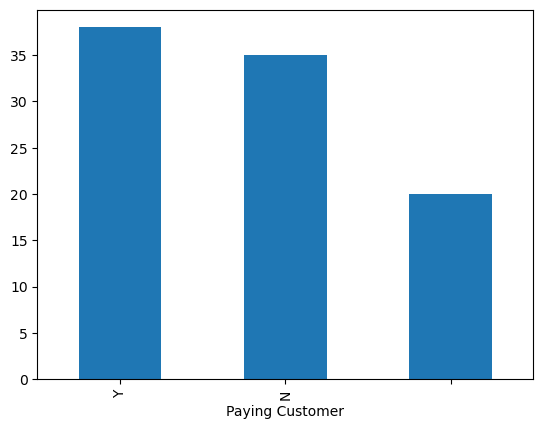

In [63]:
#number of paying customers 
df['Paying Customer'].value_counts().plot(kind='bar' )

<Axes: ylabel='State'>

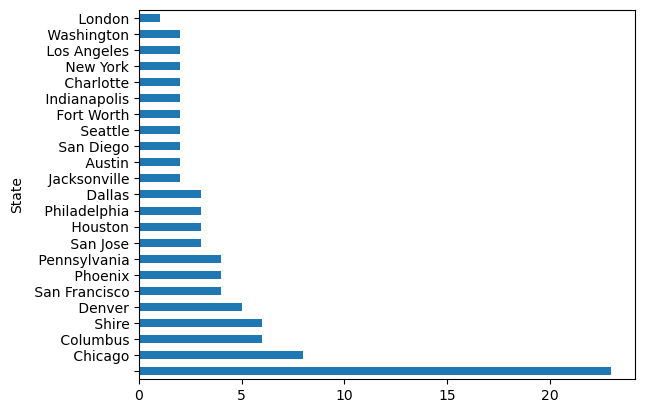

In [64]:
#number of customer from each state 
df['State'].value_counts().plot(kind='barh')

<Axes: xlabel='State'>

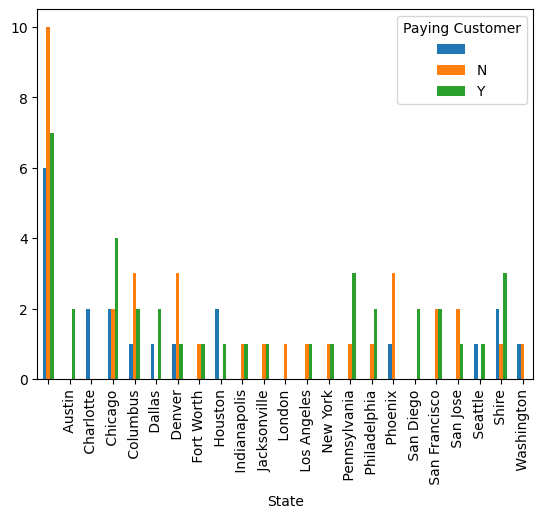

In [65]:
#number of paying customer from each state 
pd.crosstab(df['State'], df['Paying Customer']).plot(kind='bar')